# Adapting a PyTorch Tutorial to a New Dataset: Auto MPG Regression

**Original tutorial:**  
PyTorch official tutorial: *Learning PyTorch with Examples*  
https://docs.pytorch.org/tutorials/beginner/pytorch_with_examples.html

## Project goal
The original tutorial uses a simple synthetic regression example (fitting a polynomial to generated data).  
In this notebook, I adapt the same PyTorch workflow to a real-world regression problem using the **UCI Auto MPG** dataset.

## New dataset
UCI Auto MPG dataset  
https://archive.ics.uci.edu/ml/datasets/auto+mpg

## Prediction task
Predict a car's **miles per gallon (mpg)** from vehicle attributes such as cylinders, displacement, horsepower, weight, acceleration, model year, and origin.


In [11]:
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, random_split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [12]:
# Load the Auto MPG dataset from UCI
url = "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

# Only read the first 8 columns that we actually need
column_names = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin"
]

df = pd.read_csv(
    url,
    delim_whitespace=True,
    names=column_names,
    na_values="?",
    usecols=range(8)
)

print("Raw shape:", df.shape)
display(df.head())
display(df.tail())

/tmp/ipykernel_1135/1263632378.py:16: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


Raw shape: (398, 8)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,1


In [13]:
# Basic cleaning and inspection
print(df.info())
print("\nMissing values:\n", df.isna().sum())

# Drop rows with missing values
df = df.dropna().copy()

print("\nShape after dropna:", df.shape)

# Encode origin as categories instead of raw integers
origin_map = {1: "USA", 2: "Europe", 3: "Japan"}
df["origin"] = df["origin"].map(origin_map)

# One-hot encode the categorical feature
df = pd.get_dummies(df, columns=["origin"], drop_first=False)

print("\nCleaned shape:", df.shape)
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 25.0 KB
None

Missing values:
 mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

Shape after dropna: (392, 8)

Cleaned shape: (392, 10)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_Europe,origin_Japan,origin_USA
0,18.0,8,307.0,130.0,3504.0,12.0,70,False,False,True
1,15.0,8,350.0,165.0,3693.0,11.5,70,False,False,True
2,18.0,8,318.0,150.0,3436.0,11.0,70,False,False,True
3,16.0,8,304.0,150.0,3433.0,12.0,70,False,False,True
4,17.0,8,302.0,140.0,3449.0,10.5,70,False,False,True


In [14]:
# Separate features and target
X = df.drop(columns=["mpg"]).copy()
y = df["mpg"].copy()

# Ensure all columns are numeric
X = X.astype(float)
y = y.astype(float)

# Train/test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

# Standardize features based on training data only
scaler = StandardScaler()
X_train_full_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

# Convert to tensors
X_train_full_tensor = torch.tensor(X_train_full_scaled, dtype=torch.float32)
y_train_full_tensor = torch.tensor(y_train_full.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Build dataset and split train/validation
full_train_dataset = TensorDataset(X_train_full_tensor, y_train_full_tensor)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(X_test_tensor))
print("Number of input features:", X_train_full_tensor.shape[1])

Train size: 250
Validation size: 63
Test size: 79
Number of input features: 9


In [15]:
class AutoMPGRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

model = AutoMPGRegressor(input_dim=X_train_full_tensor.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

print(model)

AutoMPGRegressor(
  (network): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [16]:
def run_epoch(model, loader, criterion, optimizer=None):
    if optimizer is None:
        model.eval()
    else:
        model.train()

    total_loss = 0.0
    total_count = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if optimizer is not None:
            optimizer.zero_grad()

        preds = model(xb)
        loss = criterion(preds, yb)

        if optimizer is not None:
            loss.backward()
            optimizer.step()

        batch_size = xb.size(0)
        total_loss += loss.item() * batch_size
        total_count += batch_size

    return total_loss / total_count


num_epochs = 300
patience = 25

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

for epoch in range(num_epochs):
    train_loss = run_epoch(model, train_loader, criterion, optimizer)
    val_loss = run_epoch(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if epochs_without_improvement >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

# Restore best model
model.load_state_dict(best_state)
print("Best validation loss:", best_val_loss)

Epoch 020 | Train Loss: 24.1089 | Val Loss: 25.1283
Epoch 040 | Train Loss: 11.4673 | Val Loss: 12.7170
Epoch 060 | Train Loss: 8.8162 | Val Loss: 9.9425
Epoch 080 | Train Loss: 7.7815 | Val Loss: 9.0331
Epoch 100 | Train Loss: 7.2829 | Val Loss: 8.5256
Epoch 120 | Train Loss: 6.9121 | Val Loss: 8.2080
Epoch 140 | Train Loss: 6.6393 | Val Loss: 7.8564
Epoch 160 | Train Loss: 6.3916 | Val Loss: 7.6214
Epoch 180 | Train Loss: 6.2618 | Val Loss: 7.4515
Epoch 200 | Train Loss: 6.1191 | Val Loss: 7.3895
Epoch 220 | Train Loss: 5.9816 | Val Loss: 7.2857
Epoch 240 | Train Loss: 5.9862 | Val Loss: 7.1456
Epoch 260 | Train Loss: 5.8136 | Val Loss: 7.0633
Epoch 280 | Train Loss: 5.7552 | Val Loss: 7.0288
Epoch 300 | Train Loss: 5.9914 | Val Loss: 6.8301
Best validation loss: 6.830142974853516


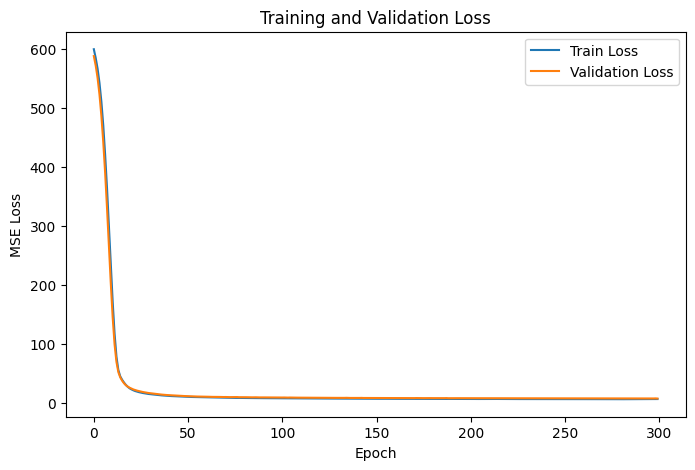

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [19]:
model.eval()

with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    preds = model(X_test_device).cpu().numpy().flatten()

y_true = y_test_tensor.numpy().flatten()

mae = mean_absolute_error(y_true, preds)
mse = mean_squared_error(y_true, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, preds)

print(f"Test MAE:  {mae:.3f}")
print(f"Test MSE:  {mse:.3f}")
print(f"Test RMSE: {rmse:.3f}")
print(f"Test R^2:  {r2:.3f}")

Test MAE:  1.743
Test MSE:  6.303
Test RMSE: 2.511
Test R^2:  0.877


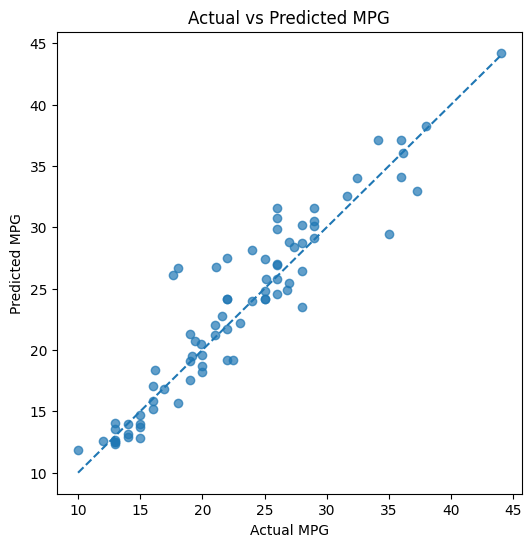

In [20]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true, preds, alpha=0.7)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], linestyle="--")
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG")
plt.show()